# Interactive Script (for development purposes only)

In [1]:
!which python

/dss/dsshome1/08/di38red/micromamba/envs/arosics/bin/python


## Caching mechanism

In [1]:
import xarray as xr
from stac2ardcube import get_stac_layers

In [2]:
stac_existing = xr.open_dataset("./results/test.nc")
stac_existing = stac_existing.Spectral_Temporal_Stack
stac_existing

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 4, band: 6, y: 247, x: 511)> Size: 24MB
[3029208 values with dtype=float64]
Coordinates:
  * y        (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x        (x) float64 4kB 6.67e+05 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
  * band     (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
  * time     (time) datetime64[ns] 32B 2024-04-06 2024-04-08 ... 2024-04-13
Attributes:
    grid_mapping:  spatial_ref

In [18]:
mission = "s2"
polygon = "./polygons/test.gpkg"
resolution = 10
daterange = ["2024-03-25", "2024-04-30"]
bands = ["blue", "green", "red", "nir",]
max_cc = 100
clip_raster = False
cloud_masking = False
indices = ["ndvi", "ndwi"]
output = None # Will return lazy, replace with path to export, preferably with DSS container path
stats = None
aggregator = None
topographic_features = None
animation = False

stac_lazy = get_stac_layers(mission=mission, polygon=polygon, resolution=resolution, 
                            daterange=daterange, bands=bands, max_cc=max_cc, 
                            clip_raster=clip_raster, cloud_masking=cloud_masking, indices=indices, 
                            output=output, aggregator=aggregator, stats=stats,
                            topographic_features=topographic_features, animation=animation)

stac_lazy

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 14, band: 6, y: 247, x: 511)> Size: 85MB
dask.array<transpose, shape=(14, 6, 247, 511), dtype=float64, chunksize=(1, 1, 247, 511), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
  * band         (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
  * time         (time) datetime64[ns] 112B 2024-03-27 2024-03-29 ... 2024-04-28
    spatial_ref  int64 8B 0


<xarray.DataArray 'Spectral_Temporal_Stack' (time: 14, band: 6, y: 247, x: 511)> Size: 85MB
dask.array<transpose, shape=(14, 6, 247, 511), dtype=float64, chunksize=(1, 1, 247, 511), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
  * band         (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
  * time         (time) datetime64[ns] 112B 2024-03-27 2024-03-29 ... 2024-04-28
    spatial_ref  int64 8B 0

In [23]:
import xarray as xr
import numpy as np

# Function to verify spatial grid compatibility between two datasets
def check_geometry_match(existing, lazy):
    # Check if both datasets have 'x' and 'y' coordinates
    for coord in ['x', 'y']:
        if coord not in existing.coords or coord not in lazy.coords:
            raise ValueError(f"Missing spatial coordinate '{coord}' in one of the datasets.")
        
        # Compare coordinate values (assumes coordinates are numpy arrays or similar)
        if not np.array_equal(existing.coords[coord].values, lazy.coords[coord].values):
            raise ValueError("The provided STAC datasets are from different regions and have incompatible spatial grids.")
    return True

# Assuming stac_existing and stac_lazy are defined xarray DataArrays
try:
    # First, check that the spatial geometries (grids) match
    check_geometry_match(stac_existing, stac_lazy)
    
    # Compare the time coordinates to determine missing dates
    existing_times = set(stac_existing.time.values)
    lazy_times = set(stac_lazy.time.values)
    
    # Identify the missing times (i.e., dates present in the lazy array but not in the computed one)
    missing_times = sorted(list(lazy_times - existing_times))
    
    # Select only the missing dates from the lazy array
    stac_lazy_missing = stac_lazy.sel(time=missing_times)
    
    # Compute the missing slices (only these will be computed now)
    computed_missing = stac_lazy_missing.compute()
    
    # Merge the computed missing data with the existing dataarray along the time dimension
    merged = xr.concat([stac_existing, computed_missing], dim="time")
    merged = merged.sortby("time")
    
    # Generate a detailed report about the update with formatted dates (date only, no time)
    num_added = len(missing_times)
    print("Update Report:")
    print("-------------------------")
    print(f"{num_added} new date{'s' if num_added != 1 else ''} have been integrated into the dataset.")
    print("The following dates were added:")
    for dt in missing_times:
        formatted_date = np.datetime_as_string(dt, unit='D')
        print(f" - {formatted_date}")
    
    # Optionally, print the merged DataArray information
    print("\nMerged STAC DataArray summary:")
    print(merged)
    
except ValueError as e:
    print("Error:", e)


Update Report:
-------------------------
10 new dates have been integrated into the dataset.
The following dates were added:
 - 2024-03-27
 - 2024-03-29
 - 2024-04-01
 - 2024-04-03
 - 2024-04-16
 - 2024-04-18
 - 2024-04-21
 - 2024-04-23
 - 2024-04-26
 - 2024-04-28

Merged STAC DataArray summary:
<xarray.DataArray 'Spectral_Temporal_Stack' (time: 14, band: 6, y: 247, x: 511)> Size: 85MB
array([[[[ 1.00000000e-04,  1.00000000e-04,  1.00000000e-04, ...,
           1.00000000e-04,  1.00000000e-04,  1.00000000e-04],
         [ 1.00000000e-04,  1.00000000e-04,  1.00000000e-04, ...,
           1.00000000e-04,  1.00000000e-04,  1.00000000e-04],
         [ 6.06000000e-02,  3.48000000e-02,  1.00000000e-04, ...,
           1.00000000e-04,  1.00000000e-04,  1.00000000e-04],
         ...,
         [ 5.62000000e-02,  7.20000000e-02,  3.78000000e-02, ...,
           1.22600000e-01,  1.00000000e-04,  1.00000000e-04],
         [ 1.00000000e-04,  1.00000000e-04,  2.58000000e-02, ...,
           6.510000

In [20]:
merged

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 14, band: 6, y: 247, x: 511)> Size: 85MB
array([[[[ 1.00000000e-04,  1.00000000e-04,  1.00000000e-04, ...,
           1.00000000e-04,  1.00000000e-04,  1.00000000e-04],
         [ 1.00000000e-04,  1.00000000e-04,  1.00000000e-04, ...,
           1.00000000e-04,  1.00000000e-04,  1.00000000e-04],
         [ 6.06000000e-02,  3.48000000e-02,  1.00000000e-04, ...,
           1.00000000e-04,  1.00000000e-04,  1.00000000e-04],
         ...,
         [ 5.62000000e-02,  7.20000000e-02,  3.78000000e-02, ...,
           1.22600000e-01,  1.00000000e-04,  1.00000000e-04],
         [ 1.00000000e-04,  1.00000000e-04,  2.58000000e-02, ...,
           6.51000000e-02,  1.00000000e-04,  1.00000000e-04],
         [ 8.40000000e-03,  1.66000000e-02,  4.94000000e-02, ...,
           1.13200000e-01,  1.00000000e-04,  1.00000000e-04]],

        [[ 1.00000000e-04,  9.20000000e-03,  4.94000000e-02, ...,
           1.00000000e-04,  1.00000000e-04,  1.00000000e-04],
         [ 1.75000000e-02,  2.11000000e-02,  1.00000000e-04, ...,
           1.00000000e-04,  1.00000000e-04,  1.00000000e-04],
         [ 7.05000000e-02,  7.76000000e-02,  2.64000000e-02, ...,
           1.00000000e-04,  1.00000000e-04,  1.00000000e-04],
...
           1.66805671e-03,  2.92519850e-03,  2.93255132e-03],
         [ 1.29701686e-03, -8.67302689e-04,  2.17485863e-03, ...,
          -4.19287212e-04, -2.52100840e-03, -1.68634064e-03],
         [-3.94563788e-03, -5.26315789e-03, -4.38596491e-03, ...,
           4.22475708e-04, -1.69204738e-03, -5.94227504e-03]],

        [[-1.54320988e-02, -1.85042406e-02, -1.54083205e-02, ...,
          -2.00668896e-02, -1.93591455e-02, -1.97522598e-02],
         [-1.57389635e-02, -1.69100692e-02, -1.53374233e-02, ...,
          -2.19560878e-02, -1.86170213e-02, -1.96078431e-02],
         [-1.68067227e-02, -1.37614679e-02, -1.33945656e-02, ...,
          -1.81578079e-02, -1.88679245e-02, -1.94912455e-02],
         ...,
         [-1.46678171e-02, -1.42302717e-02, -1.33909287e-02, ...,
          -1.13684211e-02, -7.55667506e-03, -7.57575758e-03],
         [-9.59023540e-03, -6.11353712e-03, -5.67437800e-03, ...,
          -1.05977109e-02, -4.65509945e-03, -6.37484063e-03],
         [-4.42086649e-03, -4.42869796e-03, -4.42477876e-03, ...,
          -1.11016225e-02, -9.84167736e-03, -8.17907878e-03]]]],
      shape=(14, 6, 247, 511))
Coordinates:
  * y            (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
  * band         (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
  * time         (time) datetime64[ns] 112B 2024-03-27 2024-03-29 ... 2024-04-28
    spatial_ref  int64 8B 0
Attributes:
    grid_mapping:  spatial_ref

In [21]:
def check_geometry_match(existing, lazy):
    # Check if both datasets have 'x' and 'y' coordinates
    for coord in ['x', 'y']:
        if coord not in existing.coords or coord not in lazy.coords:
            raise ValueError(f"Missing spatial coordinate '{coord}' in one of the datasets.")
        
        # Compare coordinate values (assumes coordinates are numpy arrays or similar)
        if not np.array_equal(existing.coords[coord].values, lazy.coords[coord].values):
            raise ValueError("The provided STAC datasets are from different regions and have incompatible spatial grids.")
    return True

In [22]:
check_geometry_match(stac_existing, stac_lazy)

True

## Tile extraction

In [36]:
catalog_url = 'https://earth-search.aws.element84.com/v1/'
catalog = pystacclient.open(catalog_url)

bbox_list= [100.767417,45.208589,100.783210,45.215543]
collection = 'sentinel-2-l1c'
bbox = bbox_list
start = '2020-08-29'
end = '2020-08-29'
results = catalog.search(
    bbox = bbox,
    collections=[collection],
    datetime=[start, end]
)
items = results.item_collection() #item_collection
print("%s items found" % len(items))

1 items found


In [37]:
items[0]

<Item id=S2A_21XVJ_20200829_2_L1C>

In [31]:
stac_json = items
gdf = gpd.GeoDataFrame.from_features(stac_json, "epsg:4326")

In [32]:
gdf

,geometry,created,platform,constellation,instruments,eo:cloud_cover,proj:epsg,mgrs:utm_zone,mgrs:latitude_band,mgrs:grid_square,...,s2:datatake_type,s2:datastrip_id,s2:granule_id,s2:reflectance_conversion_factor,datetime,s2:sequence,earthsearch:s3_path,earthsearch:payload_id,processing:software,updated
0,"POLYGON ((-180 90, -180 -90, 180 -90, 180 90, ...",2024-03-02T12:32:08.668Z,sentinel-2a,sentinel-2,[msi],0.8059,32623,23,X,MJ,...,INS-NOBS,S2A_OPER_MSI_L1C_DS_MPS__20180904T225053_S2018...,S2A_OPER_MSI_L1C_TL_MPS__20180904T225053_A0167...,0.982174,2018-09-04T19:29:10.455000Z,2,s3://earthsearch-data/sentinel-2-l1c/23/X/MJ/2...,roda-sentinel2/workflow-sentinel2-to-stac/5b76...,{'sentinel2-to-stac': '0.1.1'},2024-03-02T12:32:08.668Z


In [11]:
gdf = gpd.GeoDataFrame.from_features(stac_json, "epsg:4326")

# Compute granule id from components
gdf["granule"] = (
    gdf["mgrs:utm_zone"].apply(lambda x: f"{x:02d}")
    + gdf["mgrs:latitude_band"]
    + gdf["mgrs:grid_square"]
)

In [18]:
unique_values = gdf["granule"].unique()
unique_values

array(['47TPL'], dtype=object)

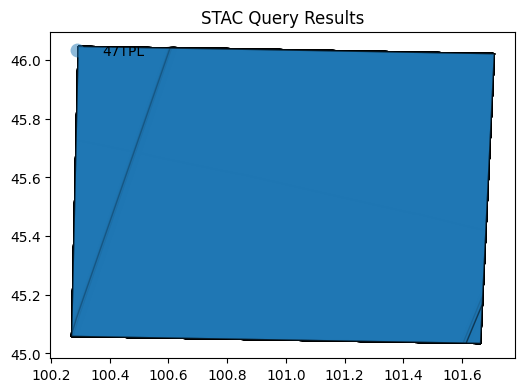

In [13]:
fig = gdf.plot(
    "granule",
    edgecolor="black",
    categorical=True,
    aspect="equal",
    alpha=0.5,
    figsize=(6, 12),
    legend=True,
    legend_kwds={"loc": "upper left", "frameon": False, "ncol": 1},
)
_ = fig.set_title("STAC Query Results")